In [1]:
import pandas as pd
import numpy as np
movies = pd.read_csv('data/imdb-top-1000.csv')
movies.head()

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0


In [2]:
genres = movies.groupby('Genre')

In [3]:
#Applying builtin aggregation function on groupby object
genres.sum('IMDB_Rating').sort_values('IMDB_Rating',ascending=False)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Drama,36049,2299.7,61367304,3.540997e+10,19208.0
Action,22196,1367.3,72282412,3.263226e+10,10499.0
Comedy,17380,1224.7,27620327,1.566387e+10,9840.0
Crime,13524,857.8,33533615,8.452632e+09,6706.0
Biography,11970,698.6,24006844,8.276358e+09,6023.0
Animation,8166,650.3,21978630,1.463147e+10,6082.0
Adventure,9656,571.5,22576163,9.496922e+09,5020.0
Mystery,1429,95.7,4203004,1.256417e+09,633.0
Horror,1123,87.0,3742556,1.034649e+09,880.0


In [4]:
genres.mean('IMDB_Rating').sort_values('IMDB_Rating',ascending=False)

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Western,148.250000,8.350000,322416.250000,1.455538e+07,78.250000
Crime,126.392523,8.016822,313398.271028,7.899656e+07,77.080460
Fantasy,85.000000,8.000000,73111.000000,3.913633e+08,NaN
Mystery,119.083333,7.975000,350250.333333,1.047014e+08,79.125000
Film-Noir,104.000000,7.966667,122405.000000,4.197018e+07,95.666667
Drama,124.737024,7.957439,212343.612457,1.225259e+08,79.701245
Action,129.046512,7.949419,420246.581395,1.897224e+08,73.419580
Biography,136.022727,7.938636,272805.045455,9.404952e+07,76.240506
Adventure,134.111111,7.937500,313557.819444,1.319017e+08,78.437500


In [5]:
movies.groupby('Genre').max('IMDB_Ratimg')

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,321,9.0,2303232,936662225.0,98.0
Adventure,228,8.6,1512360,874211619.0,100.0
Animation,137,8.6,999790,873839108.0,96.0
Biography,209,8.9,1213505,753585104.0,97.0
Comedy,188,8.6,939631,886752933.0,99.0
Crime,229,9.2,1826188,790482117.0,100.0
Drama,242,9.3,2343110,924558264.0,100.0
Family,115,7.8,372490,435110554.0,91.0
Fantasy,94,8.1,88794,445151978.0,NaN


In [6]:
#find top 3 genres by total earning
movies.groupby('Genre').sum()['Gross'].sort_values(ascending=False).head(3)

Genre
Drama     3.540997e+10
Action    3.263226e+10
Comedy    1.566387e+10
Name: Gross, dtype: float64

In [7]:
movies.groupby('Genre').sum()['Runtime'].sort_values(ascending=False).head(3)

Genre
Drama     36049
Action    22196
Comedy    17380
Name: Runtime, dtype: int64

In [8]:
#find top 3 genres by runtime
movies.groupby('Genre').sum()['Runtime'].sort_values(ascending=False).head(3)

Genre
Drama     36049
Action    22196
Comedy    17380
Name: Runtime, dtype: int64

In [9]:
#find Genre with highest avg IMDB rating
movies.groupby('Genre')['IMDB_Rating'].mean().sort_values(ascending=False).head()

Genre
Western      8.350000
Crime        8.016822
Fantasy      8.000000
Mystery      7.975000
Film-Noir    7.966667
Name: IMDB_Rating, dtype: float64

In [10]:
#find director with most popularity
movies.groupby('Director')['No_of_Votes'].sum().sort_values(ascending=False).head(3)

Director
Christopher Nolan    11578345
Quentin Tarantino     8123208
Steven Spielberg      7817166
Name: No_of_Votes, dtype: int64

In [11]:
#find no. of movies done by each actor
#movies['Star1'].value_counts()
movies.groupby('Star1')['Series_Title'].count().sort_values(ascending=False)

Star1
Tom Hanks             12
Robert De Niro        11
Clint Eastwood        10
Al Pacino             10
Leonardo DiCaprio      9
                      ..
Glen Hansard           1
Giuseppe Battiston     1
Giulietta Masina       1
Gerardo Taracena       1
Ömer Faruk Sorak       1
Name: Series_Title, Length: 660, dtype: int64

In [12]:
#find total no.of group
#movies['Genre'].nunique()
len(movies.groupby('Genre'))

14

In [13]:
#no. of movies in each genre
movies.groupby('Genre').size()

Genre
Action       172
Adventure     72
Animation     82
Biography     88
Comedy       155
Crime        107
Drama        289
Family         2
Fantasy        2
Film-Noir      3
Horror        11
Mystery       12
Thriller       1
Western        4
dtype: int64

In [14]:
#first movies of each genre
genres = movies.groupby('Genre')
genres.first()
#last movies of each genre
#genres.last()
#nth movies of each genre

,Series_Title,Released_Year,Runtime,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,
Action,The Dark Knight,2008,152,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
Adventure,Interstellar,2014,169,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
Animation,Sen to Chihiro no kamikakushi,2001,125,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
Biography,Schindler's List,1993,195,8.9,Steven Spielberg,Liam Neeson,1213505,96898818.0,94.0
Comedy,Gisaengchung,2019,132,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
Crime,The Godfather,1972,175,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
Drama,The Shawshank Redemption,1994,142,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
Family,E.T. the Extra-Terrestrial,1982,115,7.8,Steven Spielberg,Henry Thomas,372490,435110554.0,91.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,8.1,Robert Wiene,Werner Krauss,57428,337574718.0,NaN


In [15]:
#get_group give all movies of particular group
genres.get_group('Horror')

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
49,Psycho,1960,109,Horror,8.5,Alfred Hitchcock,Anthony Perkins,604211,32000000.0,97.0
75,Alien,1979,117,Horror,8.4,Ridley Scott,Sigourney Weaver,787806,78900000.0,89.0
271,The Thing,1982,109,Horror,8.1,John Carpenter,Kurt Russell,371271,13782838.0,57.0
419,The Exorcist,1973,122,Horror,8.0,William Friedkin,Ellen Burstyn,362393,232906145.0,81.0
544,Night of the Living Dead,1968,96,Horror,7.9,George A. Romero,Duane Jones,116557,89029.0,89.0
707,The Innocents,1961,100,Horror,7.8,Jack Clayton,Deborah Kerr,27007,2616000.0,88.0
724,Get Out,2017,104,Horror,7.7,Jordan Peele,Daniel Kaluuya,492851,176040665.0,85.0
844,Halloween,1978,91,Horror,7.7,John Carpenter,Donald Pleasence,233106,47000000.0,87.0
876,The Invisible Man,1933,71,Horror,7.7,James Whale,Claude Rains,30683,298791505.0,87.0
932,Saw,2004,103,Horror,7.6,James Wan,Cary Elwes,379020,56000369.0,46.0


In [16]:
#give index position of each genre group
genres.groups

{'Action': [2, 5, 8, 10, 13, 14, 16, 29, 30, 31, 39, 42, 44, 55, 57, 59, 60, 63, 68, 72, 106, 109, 129, 130, 134, 140, 142, 144, 152, 155, 160, 161, 166, 168, 171, 172, 177, 181, 194, 201, 202, 216, 217, 223, 224, 236, 241, 262, 275, 294, 308, 320, 325, 326, 331, 337, 339, 340, 343, 345, 348, 351, 353, 356, 357, 362, 368, 369, 375, 376, 390, 410, 431, 436, 473, 477, 479, 482, 488, 493, 496, 502, 507, 511, 532, 535, 540, 543, 564, 569, 570, 573, 577, 582, 583, 602, 605, 608, 615, 623, ...], 'Adventure': [21, 47, 93, 110, 114, 116, 118, 137, 178, 179, 191, 193, 209, 226, 231, 247, 267, 273, 281, 300, 301, 304, 306, 323, 329, 361, 366, 377, 402, 406, 415, 426, 458, 470, 497, 498, 506, 513, 514, 537, 549, 552, 553, 566, 576, 604, 609, 618, 638, 647, 675, 681, 686, 692, 711, 713, 739, 755, 781, 797, 798, 851, 873, 884, 912, 919, 947, 957, 964, 966, 984, 991], 'Animation': [23, 43, 46, 56, 58, 61, 66, 70, 101, 135, 146, 151, 158, 170, 197, 205, 211, 213, 219, 229, 230, 242, 245, 246, 270, 33

In [17]:
#describe all information of movies dataset 
movies.describe()

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
count,1000.000000,1000.000000,1.000000e+03,1.000000e+03,843.000000
mean,122.891000,7.949300,2.736929e+05,1.282781e+08,77.971530
std,28.093671,0.275491,3.273727e+05,2.011110e+08,12.376099
min,45.000000,7.600000,2.508800e+04,1.305000e+03,28.000000
25%,103.000000,7.700000,5.552625e+04,5.012919e+06,70.000000
50%,119.000000,7.900000,1.385485e+05,3.953432e+07,79.000000
75%,137.000000,8.100000,3.741612e+05,1.615997e+08,87.000000
max,321.000000,9.300000,2.343110e+06,9.366622e+08,100.000000


In [18]:
#describe genres information
genres.describe()

Runtime                                                              \
            count        mean        std    min     25%    50%     75%    max   
Genre                                                                           
Action      172.0  129.046512  28.500706   45.0  110.75  127.5  143.25  321.0   
Adventure    72.0  134.111111  33.317320   88.0  109.00  127.0  149.00  228.0   
Animation    82.0   99.585366  14.530471   71.0   90.00   99.5  106.75  137.0   
Biography    88.0  136.022727  25.514466   93.0  120.00  129.0  146.25  209.0   
Comedy      155.0  112.129032  22.946213   68.0   96.00  106.0  124.50  188.0   
Crime       107.0  126.392523  27.689231   80.0  106.50  122.0  141.50  229.0   
Drama       289.0  124.737024  27.740490   64.0  105.00  121.0  137.00  242.0   
Family        2.0  107.500000  10.606602  100.0  103.75  107.5  111.25  115.0   
Fantasy       2.0   85.000000  12.727922   76.0   80.50   85.0   89.50   94.0   
Film-Noir     3.0  104.000000   4.000000  100.0  102.00  104.0  106.00  108.0   
Horror       11.0  102.090909  13.604812   71.0   98.00  103.0  109.00  122.0   
Mystery      12.0  119.083333  14.475423   96.0  110.75  117.5  130.25  138.0   
Thriller      1.0  108.000000        NaN  108.0  108.00  108.0  108.00  108.0   
Western       4.0  148.250000  17.153717  132.0  134.25  148.0  162.00  165.0   

          IMDB_Rating            ...         Gross              Metascore  \
                count      mean  ...           75%          max     count   
Genre                            ...                                        
Action          172.0  7.949419  ...  2.674437e+08  936662225.0     143.0   
Adventure        72.0  7.937500  ...  1.998070e+08  874211619.0      64.0   
Animation        82.0  7.930488  ...  2.520612e+08  873839108.0      75.0   
Biography        88.0  7.938636  ...  9.829924e+07  753585104.0      79.0   
Comedy          155.0  7.901290  ...  8.107809e+07  886752933.0     125.0   
Crime           107.0  8.016822  ...  7.102163e+07  790482117.0      87.0   
Drama           289.0  7.957439  ...  1.164461e+08  924558264.0     241.0   
Family            2.0  7.800000  ...  3.273329e+08  435110554.0       2.0   
Fantasy           2.0  8.000000  ...  4.182577e+08  445151978.0       0.0   
Film-Noir         3.0  7.966667  ...  6.273068e+07  123353292.0       3.0   
Horror           11.0  7.909091  ...  1.362817e+08  298791505.0      11.0   
Mystery          12.0  7.975000  ...  1.310949e+08  474203697.0       8.0   
Thriller          1.0  7.800000  ...  1.755074e+07   17550741.0       1.0   
Western           4.0  8.350000  ...  1.920000e+07   31800000.0       4.0   

                                                                  
                mean        std   min    25%   50%    75%    max  
Genre                                                             
Action     73.419580  12.421252  33.0  65.00  74.0  82.00   98.0  
Adventure  78.437500  12.345393  41.0  69.75  80.5  87.25  100.0  
Animation  81.093333   8.813646  61.0  75.00  82.0  87.50   96.0  
Biography  76.240506  11.028187  48.0  70.50  76.0  84.50   97.0  
Comedy     78.720000  11.829160  45.0  72.00  79.0  88.00   99.0  
Crime      77.080460  13.099102  47.0  69.50  77.0  87.00  100.0  
Drama      79.701245  12.744687  28.0  72.00  82.0  89.00  100.0  
Family     79.000000  16.970563  67.0  73.00  79.0  85.00   91.0  
Fantasy          NaN        NaN   NaN    NaN   NaN    NaN    NaN  
Film-Noir  95.666667   1.527525  94.0  95.00  96.0  96.50   97.0  
Horror     80.000000  15.362291  46.0  77.50  87.0  88.50   97.0  
Mystery    79.125000  18.604435  52.0  65.25  77.0  98.50  100.0  
Thriller   81.000000        NaN  81.0  81.00  81.0  81.00   81.0  
Western    78.250000   9.032349  69.0  72.75  77.0  82.50   90.0  

[14 rows x 40 columns]

In [19]:
#random movies form each genre
#genres.sample()
genres.sample(2,replace=True)

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
13,The Lord of the Rings: The Two Towers,2002,179,Action,8.7,Peter Jackson,Elijah Wood,1485555,342551365.0,87.0
351,Yip Man,2008,106,Action,8.0,Wilson Yip,Donnie Yen,211427,613703997.0,59.0
873,The African Queen,1951,105,Adventure,7.7,John Huston,Humphrey Bogart,71481,536118.0,91.0
686,The Right Stuff,1983,193,Adventure,7.8,Philip Kaufman,Sam Shepard,56235,21500000.0,91.0
518,Mimi wo sumaseba,1995,111,Animation,7.9,Yoshifumi Kondô,Yoko Honna,51943,252243550.0,75.0
135,Klaus,2019,96,Animation,8.2,Sergio Pablos,Carlos Martínez López,104761,148596026.0,65.0
411,Gandhi,1982,191,Biography,8.0,Richard Attenborough,Ben Kingsley,217664,52767889.0,79.0
673,Glory,1989,122,Biography,7.8,Edward Zwick,Matthew Broderick,122779,26830000.0,78.0
594,English Vinglish,2012,134,Comedy,7.8,Gauri Shinde,Sridevi,33618,1670773.0,NaN
817,Short Cuts,1993,188,Comedy,7.7,Robert Altman,Andie MacDowell,42275,6110979.0,79.0


In [20]:
#agg methode
#passing dict
genres.agg(
{
    'Runtime':'mean',
    'IMDB_Rating':'mean',
    'No_of_Votes':'sum',
    'Gross':'sum',
    'Metascore':'min'
})

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
Genre,,,,,
Action,129.046512,7.949419,72282412,3.263226e+10,33.0
Adventure,134.111111,7.937500,22576163,9.496922e+09,41.0
Animation,99.585366,7.930488,21978630,1.463147e+10,61.0
Biography,136.022727,7.938636,24006844,8.276358e+09,48.0
Comedy,112.129032,7.901290,27620327,1.566387e+10,45.0
Crime,126.392523,8.016822,33533615,8.452632e+09,47.0
Drama,124.737024,7.957439,61367304,3.540997e+10,28.0
Family,107.500000,7.800000,551221,4.391106e+08,67.0
Fantasy,85.000000,8.000000,146222,7.827267e+08,NaN


In [21]:
genres['Runtime'].agg(['min','max','mean'])

,min,max,mean
Genre,,,
Action,45,321,129.046512
Adventure,88,228,134.111111
Animation,71,137,99.585366
Biography,93,209,136.022727
Comedy,68,188,112.129032
Crime,80,229,126.392523
Drama,64,242,124.737024
Family,100,115,107.500000
Fantasy,76,94,85.000000


In [22]:
genres['IMDB_Rating'].agg(['min','max','mean'])

,min,max,mean
Genre,,,
Action,7.6,9.0,7.949419
Adventure,7.6,8.6,7.937500
Animation,7.6,8.6,7.930488
Biography,7.6,8.9,7.938636
Comedy,7.6,8.6,7.901290
Crime,7.6,9.2,8.016822
Drama,7.6,9.3,7.957439
Family,7.8,7.8,7.800000
Fantasy,7.9,8.1,8.000000


In [23]:
#loop in group
for group,data in genres:
    print(data)

                                          Series_Title Released_Year  Runtime  \
2                                      The Dark Knight          2008      152   
5        The Lord of the Rings: The Return of the King          2003      201   
8                                            Inception          2010      148   
10   The Lord of the Rings: The Fellowship of the Ring          2001      178   
13               The Lord of the Rings: The Two Towers          2002      179   
..                                                 ...           ...      ...   
968                                       Falling Down          1993      113   
979                                      Lethal Weapon          1987      109   
982                                          Mad Max 2          1981       96   
983                                       The Warriors          1979       92   
985                               Escape from Alcatraz          1979      112   

      Genre  IMDB_Rating   

In [24]:
#find the highest rated movies form each genre
df = pd.DataFrame(columns = movies.columns)
for group,data in genres:
    df =(data[data['IMDB_Rating'] == data["IMDB_Rating"].max()])

df

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
12,"Il buono, il brutto, il cattivo",1966,161,Western,8.8,Sergio Leone,Clint Eastwood,688390,6100000.0,90.0


In [25]:
#apply function
genres.apply(min)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\1477424214.py:2: FutureWarning: The provided callable <built-in function min> is currently using np.minimum.reduce. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string np.minimum.reduce instead.
  genres.apply(min)
C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\1477424214.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(min)


,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
Genre,,,,,,,,,,
Action,300,1924,45,Action,7.6,Abhishek Chaubey,Aamir Khan,25312,3296.0,NaN
Adventure,2001: A Space Odyssey,1925,88,Adventure,7.6,Akira Kurosawa,Aamir Khan,29999,61001.0,NaN
Animation,Akira,1940,71,Animation,7.6,Adam Elliot,Adrian Molina,25229,128985.0,NaN
Biography,12 Years a Slave,1928,93,Biography,7.6,Adam McKay,Adrien Brody,27254,21877.0,NaN
Comedy,(500) Days of Summer,1921,68,Comedy,7.6,Alejandro G. Iñárritu,Aamir Khan,26337,1305.0,NaN
Crime,12 Angry Men,1931,80,Crime,7.6,Akira Kurosawa,Ajay Devgn,27712,6013.0,NaN
Drama,1917,1925,64,Drama,7.6,Aamir Khan,Abhay Deol,25088,3600.0,NaN
Family,E.T. the Extra-Terrestrial,1971,100,Family,7.8,Mel Stuart,Gene Wilder,178731,4000000.0,67.0
Fantasy,Das Cabinet des Dr. Caligari,1920,76,Fantasy,7.9,F.W. Murnau,Max Schreck,57428,337574718.0,NaN


In [26]:
def foo(group):
    group['Series_Title']
    return group
genres.apply(foo)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\2084320763.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(foo)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  
Genre                                                                 
Action   2       Christian Bale      2303232  534858444.0       84.0  
         5          Elijah Wood      1642758  377845905.0       94.0  
         8    Leonardo DiCaprio      2067042  292576195.0       74.0  
         10         Elijah Wood      1661481  315544750.0       92.0  
         13         Elijah Wood      1485555  342551365.0       87.0  
...                         ...          ...          ...        ...  
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0  
Western  12      Clint Eastwood       688390    6100000.0       90.0  
         48         Henry Fonda       302844    5321508.0       80.0  
         115     Clint Eastwood       232772   15000000.0       74.0  
         691     Clint Eastwood        65659   31800000.0       69.0  

[1000 rows x 10 columns]

In [27]:
def foo(group):
    return group['Series_Title'].str.startswith('A')
genres.apply(foo)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\3282645354.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(foo)


Genre        
Action    2      False
          5      False
          8      False
          10     False
          13     False
                 ...  
Thriller  700    False
Western   12     False
          48     False
          115    False
          691    False
Name: Series_Title, Length: 1000, dtype: bool

In [28]:
#find number of movies starting with A in each genre
def foo(group):
    return group['Series_Title'].str.startswith('A').sum() 

genres.apply(foo)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\1706328487.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(foo)


Genre
Action       10
Adventure     2
Animation     2
Biography     9
Comedy       14
Crime         4
Drama        21
Family        0
Fantasy       0
Film-Noir     0
Horror        1
Mystery       0
Thriller      0
Western       0
dtype: int64

In [29]:
#find the rank of each movies in thier genre according to IMDB_Score
def rank_movies(group):
    group['genre_rank']=group['IMDB_Rating'].rank(ascending=False)
    return group

genres.apply(rank_movies)

C:\Users\narendra tekale\AppData\Local\Temp\ipykernel_14308\1801832488.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  genres.apply(rank_movies)


Series_Title Released_Year  \
Genre                                                                           
Action   2                                      The Dark Knight          2008   
         5        The Lord of the Rings: The Return of the King          2003   
         8                                            Inception          2010   
         10   The Lord of the Rings: The Fellowship of the Ring          2001   
         13               The Lord of the Rings: The Two Towers          2002   
...                                                         ...           ...   
Thriller 700                                    Wait Until Dark          1967   
Western  12                     Il buono, il brutto, il cattivo          1966   
         48                        Once Upon a Time in the West          1968   
         115                         Per qualche dollaro in più          1965   
         691                             The Outlaw Josey Wales          1976   

              Runtime     Genre  IMDB_Rating           Director  \
Genre                                                             
Action   2        152    Action          9.0  Christopher Nolan   
         5        201    Action          8.9      Peter Jackson   
         8        148    Action          8.8  Christopher Nolan   
         10       178    Action          8.8      Peter Jackson   
         13       179    Action          8.7      Peter Jackson   
...               ...       ...          ...                ...   
Thriller 700      108  Thriller          7.8      Terence Young   
Western  12       161   Western          8.8       Sergio Leone   
         48       165   Western          8.5       Sergio Leone   
         115      132   Western          8.3       Sergio Leone   
         691      135   Western          7.8     Clint Eastwood   

                          Star1  No_of_Votes        Gross  Metascore  \
Genre                                                                  
Action   2       Christian Bale      2303232  534858444.0       84.0   
         5          Elijah Wood      1642758  377845905.0       94.0   
         8    Leonardo DiCaprio      2067042  292576195.0       74.0   
         10         Elijah Wood      1661481  315544750.0       92.0   
         13         Elijah Wood      1485555  342551365.0       87.0   
...                         ...          ...          ...        ...   
Thriller 700     Audrey Hepburn        27733   17550741.0       81.0   
Western  12      Clint Eastwood       688390    6100000.0       90.0   
         48         Henry Fonda       302844    5321508.0       80.0   
         115     Clint Eastwood       232772   15000000.0       74.0   
         691     Clint Eastwood        65659   31800000.0       69.0   

              genre_rank  
Genre                     
Action   2           1.0  
         5           2.0  
         8           3.5  
         10          3.5  
         13          6.0  
...                  ...  
Thriller 700         1.0  
Western  12          1.0  
         48          2.0  
         115         3.0  
         691         4.0  

[1000 rows x 11 columns]

In [30]:
#groupby multiple column
duo = movies.groupby(['Director','Star1'])
duo.size()
duo.get_group(('Aamir Khan','Amole Gupte'))

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN


In [31]:
#find most earning actor->director combo
duo['Gross'].sum().sort_values(ascending=False)

Director              Star1          
Akira Kurosawa        Toshirô Mifune     2.999877e+09
Anthony Russo         Joe Russo          2.205039e+09
Billy Wilder          William Holden     1.286779e+09
Christopher Nolan     Christian Bale     1.242940e+09
Werner Herzog         Klaus Kinski       1.124605e+09
                                             ...     
Jeong-beom Lee        Won Bin            6.460000e+03
Shane Meadows         Paddy Considine    6.013000e+03
Jaco Van Dormael      Jared Leto         3.600000e+03
Thomas Jahn           Til Schweiger      3.296000e+03
Anders Thomas Jensen  Ulrich Thomsen     1.305000e+03
Name: Gross, Length: 898, dtype: float64

In [32]:
ipl = pd.read_csv("data/deliveries.csv")
ipl

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179073,11415,2,Chennai Super Kings,Mumbai Indians,20,2,RA Jadeja,SR Watson,SL Malinga,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
179074,11415,2,Chennai Super Kings,Mumbai Indians,20,3,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN
179075,11415,2,Chennai Super Kings,Mumbai Indians,20,4,SR Watson,RA Jadeja,SL Malinga,0,...,0,0,0,0,1,0,1,SR Watson,run out,KH Pandya
179076,11415,2,Chennai Super Kings,Mumbai Indians,20,5,SN Thakur,RA Jadeja,SL Malinga,0,...,0,0,0,0,2,0,2,NaN,NaN,NaN


In [33]:
batsman = ipl.groupby('batsman')
batsman

In [34]:
batsman['batsman_runs'].sum().sort_values(ascending=False).head(10)

batsman
V Kohli           5434
SK Raina          5415
RG Sharma         4914
DA Warner         4741
S Dhawan          4632
CH Gayle          4560
MS Dhoni          4477
RV Uthappa        4446
AB de Villiers    4428
G Gambhir         4223
Name: batsman_runs, dtype: int64

In [35]:
batsman_six = ipl[ipl['batsman_runs'] == 6 ]

In [36]:
batsman_six.groupby('batsman')['batsman'].value_counts().sort_values(ascending=False).head(10)

batsman
CH Gayle          327
AB de Villiers    214
MS Dhoni          207
SK Raina          195
RG Sharma         194
V Kohli           191
DA Warner         181
SR Watson         177
KA Pollard        175
YK Pathan         161
Name: count, dtype: int64

In [37]:
batsman_four = ipl[ipl['batsman_runs'] == 4]

In [38]:
batsman_four.groupby('batsman')['batsman'].value_counts().sort_values(ascending=False).head(10)

batsman
S Dhawan      526
SK Raina      495
G Gambhir     492
V Kohli       482
DA Warner     459
RV Uthappa    436
RG Sharma     431
AM Rahane     405
CH Gayle      376
PA Patel      366
Name: count, dtype: int64

In [39]:
#virat kohli runs againest each  team
team_df = ipl[ipl['batsman'] == 'V Kohli']
team_df

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
2590,12,1,Royal Challengers Bangalore,Mumbai Indians,1,2,V Kohli,CH Gayle,TG Southee,0,...,0,0,0,0,0,1,1,NaN,NaN,NaN
2591,12,1,Royal Challengers Bangalore,Mumbai Indians,1,3,V Kohli,CH Gayle,TG Southee,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
2593,12,1,Royal Challengers Bangalore,Mumbai Indians,1,5,V Kohli,CH Gayle,TG Southee,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2594,12,1,Royal Challengers Bangalore,Mumbai Indians,1,6,V Kohli,CH Gayle,TG Southee,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
2597,12,1,Royal Challengers Bangalore,Mumbai Indians,2,1,V Kohli,CH Gayle,Harbhajan Singh,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177522,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,1,7,V Kohli,AB de Villiers,B Kumar,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN
177523,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,1,V Kohli,AB de Villiers,K Ahmed,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
177524,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,2,V Kohli,AB de Villiers,K Ahmed,0,...,0,0,0,0,6,0,6,NaN,NaN,NaN
177525,11345,2,Royal Challengers Bangalore,Sunrisers Hyderabad,2,3,V Kohli,AB de Villiers,K Ahmed,0,...,0,0,0,0,1,0,1,NaN,NaN,NaN


In [40]:
team_df.groupby('bowling_team')['batsman_runs'].sum()

bowling_team
Chennai Super Kings        749
Deccan Chargers            306
Delhi Capitals              66
Delhi Daredevils           763
Gujarat Lions              283
Kings XI Punjab            636
Kochi Tuskers Kerala        50
Kolkata Knight Riders      675
Mumbai Indians             628
Pune Warriors              128
Rajasthan Royals           370
Rising Pune Supergiant      83
Rising Pune Supergiants    188
Sunrisers Hyderabad        509
Name: batsman_runs, dtype: int64

In [41]:
#highest run scored by virat kohli
highest = ipl[ipl['batsman'] == 'V Kohli']
highest.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]

113

In [42]:
#function to calculate highest run by each  team
def best_score(batsman):
    highest = ipl[ipl['batsman'] == batsman]
    return highest.groupby('match_id')['batsman_runs'].sum().sort_values(ascending=False).head(1).values[0]
    

In [43]:
best_score('CH Gayle')

175

# Advance Pandas

In [44]:
import numpy as np
import pandas as pd

students = pd.read_csv('data/students.csv')
nov = pd.read_csv('data/reg-month1.csv')
dec = pd.read_csv('data/reg-month2.csv')
matches = pd.read_csv('data/matches.csv')
deliveries = pd.read_csv('data/deliveries.csv')
courses = pd.read_csv('data/courses.csv')

In [45]:
#combin two dataset vertically
regs = pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [46]:
#multi-index dataframe
multi = pd.concat([nov,dec],keys=['Nov','Dec'])
multi.loc[('Nov',1)]

student_id    15
course_id      5
Name: (Nov, 1), dtype: int64

In [47]:
#combine two dataset vertically
#pd.concat([nov,dec])
regs = pd.concat([nov,dec],ignore_index=True)
regs

,student_id,course_id
0,23,1
1,15,5
2,18,6
3,23,4
4,16,9
5,18,1
6,1,1
7,7,8
8,22,3
9,15,1


In [48]:
#multiindex dataframe
multi = pd.concat([nov,dec],keys=['Nov','Dec'])

In [49]:
#How to access multi index dataframe
multi.loc['Dec'] #all dec data
multi.loc[('Dec',6)] # only 6th index data

student_id    7
course_id     2
Name: (Dec, 6), dtype: int64

In [50]:
#combin two dataset horizontally
pd.concat([nov,dec],axis=1)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


In [51]:
pd.concat([nov,dec],axis=1).fillna(0)

,student_id,course_id,student_id,course_id
0,23.0,1.0,3,5
1,15.0,5.0,16,7
2,18.0,6.0,12,10
3,23.0,4.0,12,1
4,16.0,9.0,14,9
5,18.0,1.0,7,7
6,1.0,1.0,7,2
7,7.0,8.0,16,3
8,22.0,3.0,17,10
9,15.0,1.0,11,8


## Merge

In [52]:
#inner join
students

,student_id,name,partner
0,1,Kailash Harjo,23
1,2,Esha Butala,1
2,3,Parveen Bhalla,3
3,4,Marlo Dugal,14
4,5,Kusum Bahri,6
5,6,Lakshmi Contractor,10
6,7,Tarun Thaker,9
7,8,Radheshyam Dey,5
8,9,Nitika Chatterjee,4
9,10,Aayushman Sant,8


In [53]:
#leftTable.merge(rightTable,how='inner',on='common_column')
students.merge(regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [54]:
#left join
courses.merge(regs,how='left',on='course_id')

,course_id,course_name,price,student_id
0,1,python,2499,23.0
1,1,python,2499,18.0
2,1,python,2499,1.0
3,1,python,2499,15.0
4,1,python,2499,21.0
5,1,python,2499,25.0
6,1,python,2499,12.0
7,1,python,2499,14.0
8,1,python,2499,38.0
9,2,sql,3499,19.0


In [55]:
#right join
temp_df = pd.DataFrame({
    'student_id':[26,27,28],
    'name':['Nitin','Ankit','Rahul'],
    'partner':[28,26,17]
})

students = pd.concat([students,temp_df],ignore_index=True)

In [56]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [57]:
students.merge(regs,how='right',on='student_id')

,student_id,name,partner,course_id
0,23,Chhavi Lachman,18.0,1
1,15,Preet Sha,16.0,5
2,18,Fardeen Mahabir,13.0,6
3,23,Chhavi Lachman,18.0,4
4,16,Elias Dodiya,25.0,9
5,18,Fardeen Mahabir,13.0,1
6,1,Kailash Harjo,23.0,1
7,7,Tarun Thaker,9.0,8
8,22,Yash Sethi,21.0,3
9,15,Preet Sha,16.0,1


In [58]:
#outer join
students.merge(regs,how='outer',on='student_id').tail(10)

,student_id,name,partner,course_id
53,23,Chhavi Lachman,18.0,5.0
54,24,Radhika Suri,17.0,4.0
55,25,Shashank D’Alia,2.0,1.0
56,25,Shashank D’Alia,2.0,10.0
57,26,Nitin,28.0,NaN
58,27,Ankit,26.0,NaN
59,28,Rahul,17.0,NaN
60,38,NaN,NaN,1.0
61,42,NaN,NaN,9.0
62,50,NaN,NaN,8.0


In [74]:
#find total revenue generated
revenue = regs.merge(courses,how='inner',on='course_id')['price'].sum()
revenue

154247

In [75]:
#find month by month revenue
novrev = nov.merge(courses,how='inner',on='course_id')['price'].sum()
decrev = dec.merge(courses,how='inner',on='course_id')['price'].sum()
novrev

89175

In [61]:
#Print the registration table
regs.merge(students , on='student_id').merge(courses,on='course_id')[['name','course_name','price']]

,name,course_name,price
0,Chhavi Lachman,python,2499
1,Preet Sha,tableau,2499
2,Fardeen Mahabir,power bi,1899
3,Chhavi Lachman,machine learning,9999
4,Elias Dodiya,plotly,699
5,Fardeen Mahabir,python,2499
6,Kailash Harjo,python,2499
7,Tarun Thaker,pandas,1099
8,Yash Sethi,data analysis,4999
9,Preet Sha,python,2499


<Axes: xlabel='course_name'>

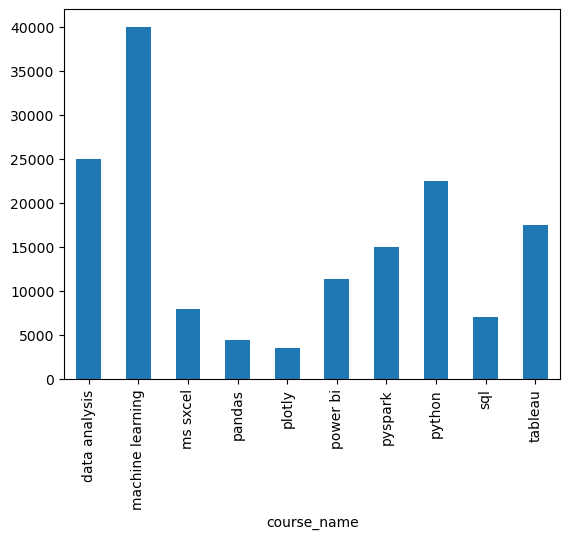

In [86]:
regs.merge(courses,on='course_id').groupby('course_name')['price'].sum().plot(kind='bar')

In [63]:
#find students who enrolled in both the months
common_student_id = np.intersect1d(nov['student_id'],dec['student_id'])
common_student_id

array([ 1,  3,  7, 11, 16, 17, 18, 22, 23], dtype=int64)

In [64]:
#find course that got no enrollment
course_id_list = np.setdiff1d(courses['course_id'],regs['course_id'])
courses[courses['course_id'].isin(course_id_list)]

,course_id,course_name,price
10,11,Numpy,699
11,12,C++,1299


In [65]:
# find students who did not enrollinto any courses
student_id_list = np.setdiff1d(students['student_id'],regs['student_id'])
students[students['student_id'].isin(student_id_list)].shape[0]

(7/28)*100

25.0

In [66]:
#print student name--partner name for all enrolled students
#self join
students.merge(students,how='inner',left_on='partner',right_on='student_id')[['name_x','name_y']]

,name_x,name_y
0,Kailash Harjo,Chhavi Lachman
1,Esha Butala,Kailash Harjo
2,Parveen Bhalla,Parveen Bhalla
3,Marlo Dugal,Pranab Natarajan
4,Kusum Bahri,Lakshmi Contractor
5,Lakshmi Contractor,Aayushman Sant
6,Tarun Thaker,Nitika Chatterjee
7,Radheshyam Dey,Kusum Bahri
8,Nitika Chatterjee,Marlo Dugal
9,Aayushman Sant,Radheshyam Dey


In [67]:
#find top 3 students who did most number enrollments
regs.merge(students,on='student_id').groupby(['student_id','name'])['name'].count().sort_values(ascending=False).head(3)

student_id  name          
23          Chhavi Lachman    6
7           Tarun Thaker      5
1           Kailash Harjo     4
Name: name, dtype: int64

In [68]:
#find top 3 students who spent most amount of maney on courses
regs.merge(students,on='student_id').merge(courses,on='course_id').groupby(['student_id','name'])['price'].sum().sort_values(ascending=False).head(3)

student_id  name            
23          Chhavi Lachman      22594
14          Pranab Natarajan    15096
19          Qabeel Raman        13498
Name: price, dtype: int64

In [69]:
#Alternate syntax for merge
pd.merge(students,regs,how='inner',on='student_id')

,student_id,name,partner,course_id
0,1,Kailash Harjo,23,1
1,1,Kailash Harjo,23,6
2,1,Kailash Harjo,23,10
3,1,Kailash Harjo,23,9
4,2,Esha Butala,1,5
5,3,Parveen Bhalla,3,3
6,3,Parveen Bhalla,3,5
7,7,Tarun Thaker,9,8
8,7,Tarun Thaker,9,10
9,7,Tarun Thaker,9,7


In [70]:
#find top 3 stadiums with highest sixes/match ratio
temp_df = deliveries.merge(matches,left_on='match_id',right_on='id')
six_df = temp_df[temp_df['batsman_runs'] == 6]
num_sixes = six_df.groupby('venue')['venue'].count()
num_matches = matches['venue'].value_counts()
ratio = num_sixes/num_matches
ratio.sort_values(ascending=False)#find top 3 stadiums with highest sixes/match ratio
temp_df = deliveries.merge(matches,left_on='match_id',right_on='id')
six_df = temp_df[temp_df['batsman_runs'] == 6]
num_sixes = six_df.groupby('venue')['venue'].count()
num_matches = matches['venue'].value_counts()
ratio = num_sixes/num_matches
ratio.sort_values(ascending=False)

venue
Holkar Cricket Stadium                                  17.600000
M Chinnaswamy Stadium                                   13.227273
Sharjah Cricket Stadium                                 12.666667
Himachal Pradesh Cricket Association Stadium            12.000000
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     11.727273
Wankhede Stadium                                        11.526316
De Beers Diamond Oval                                   11.333333
Maharashtra Cricket Association Stadium                 11.266667
JSCA International Stadium Complex                      10.857143
Sardar Patel Stadium, Motera                            10.833333
Feroz Shah Kotla                                        10.600000
MA Chidambaram Stadium, Chepauk                         10.562500
Saurashtra Cricket Association Stadium                  10.400000
Brabourne Stadium                                       10.363636
Dr DY Patil Sports Academy                              10.176471
Raji

In [71]:
#find orange cap holder of all the sasons
temp_df.groupby(['season','batsman'])['batsman_runs'].sum().reset_index().sort_values('batsman_runs',ascending=False).drop_duplicates(subset=['season'],keep='first').sort_values('season')

,season,batsman,batsman_runs
115,2008,SE Marsh,616
229,2009,ML Hayden,572
446,2010,SR Tendulkar,618
502,2011,CH Gayle,608
684,2012,CH Gayle,733
910,2013,MEK Hussey,733
1088,2014,RV Uthappa,660
1148,2015,DA Warner,562
1383,2016,V Kohli,973
1422,2017,DA Warner,641
